# Sistema de Evaluacion Automatizada — Crédito Terra
## Banco Guayaquil - Sostenibilidad
### Proyecto Integrador — Maestría en Inteligencia Artificial Aplicada

---

**Flujos operativos:**
- Flujo 1: `python src/procesar_ficha.py <ficha.xlsx>` — evaluacion formal
- Flujo 2: `streamlit run src/app.py` — estimador preliminar (usa el modelo entrenado en este notebook)
- Flujo 3: Este notebook — analisis de portafolio + entrenamiento ML + reporte

**Nota metodologica:**
El sistema experto basado en reglas es el mecanismo oficial de evaluacion.
El modelo ML es una demostracion metodologica que se activara en produccion
con 200 casos reales (Riley et al., 2019). El modelo entrenado aqui se guarda
en `models/modelo_estimacion.pkl` y es consumido automaticamente por la app Streamlit.

In [1]:
# Celda 1 — Configuracion
import sys, os, warnings
warnings.filterwarnings('ignore')
sys.path.append(os.path.join(os.getcwd(), '..', 'src'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from pathlib import Path

plt.style.use('seaborn-v0_8')
matplotlib.rcParams['figure.figsize'] = (12, 5)

from base_datos import crear_conexion, cargar_portafolio_df, consultar_portafolio

DB_PATH = '../database/credito_terra.db'
MODELS_PATH = '../models'

print('Configuracion completada')
print(f'Directorio de trabajo: {os.getcwd()}')

Configuracion completada
Directorio de trabajo: c:\Users\r7\OneDrive - Universidad Internacional del Ecuador\IA\prerrequisitos\proyecto\credito_terra\notebooks


In [2]:
# Celda 2 — Cargar portafolio desde base de datos
conn = crear_conexion(DB_PATH)
df = cargar_portafolio_df(conn)
kpis = consultar_portafolio(conn)
conn.close()

df['cumple_elegibilidad'] = df['cumple_elegibilidad'].astype(bool)

print(f'Portafolio cargado: {len(df)} casos evaluados')
print(f'Sectores: {df["sector_bg"].nunique()} | Segmentos: {df["segmento"].nunique()}')
df[['id_caso','razon_social','sector_bg','segmento','etapa','monto_credito_usd','dictamen']].head(5)

Portafolio cargado: 201 casos evaluados
Sectores: 15 | Segmentos: 3


,id_caso,razon_social,sector_bg,segmento,etapa,monto_credito_usd,dictamen
0,CT-20260518222847,MODERNA ALIMENTOS,INDUSTRIA ALIMENTICIA,Corporativo,Prefactibilidad,300000.00,CUMPLE
1,CT-OP-926321,Empresa Telecomunica 199 S.A.,TELECOMUNICACIONES,Empresarial,Ejecución,751735.50,NO CUMPLE
2,CT-OP-994473,Empresa Cacao 200 S.A.,CACAO,Corporativo,Factibilidad,1651047.05,CUMPLE
3,CT-OP-393952,Empresa Agropecuario 193 S.A.,AGROPECUARIO,Corporativo,Prefactibilidad,3300975.22,NO CUMPLE
4,CT-OP-114773,Empresa Agropecuario 194 S.A.,AGROPECUARIO,Empresarial,Prefactibilidad,605180.79,CUMPLE


In [3]:
# Celda 3 — KPIs del portafolio
print('='*58)
print('   KPIs PORTAFOLIO CREDITO TERRA — BANCO GUAYAQUIL')
print('='*58)
print(f"   Total casos evaluados:       {kpis['total_casos']}")
print(f"   Casos CUMPLEN:               {kpis['casos_cumplen']} ({kpis['tasa_aprobacion_pct']}%)")
print(f"   Casos NO CUMPLEN:            {kpis['casos_no_cumplen']}")
print(f"   Monto total evaluado:        ${kpis['monto_total_evaluado_usd']:,.2f}")
print(f"   Monto promedio por caso:     ${kpis['monto_promedio_usd']:,.2f}")
print(f"   GEI evitadas anuales:        {kpis['gei_anual_evitadas_tco2']:,.2f} tCO2/anio")
print(f"   GEI evitadas totales:        {kpis['gei_total_evitadas_tco2']:,.2f} tCO2")
print(f"   Capacidad total instalada:   {kpis['capacidad_total_mwp']} MWp")
print('='*58)

   KPIs PORTAFOLIO CREDITO TERRA — BANCO GUAYAQUIL
   Total casos evaluados:       201
   Casos CUMPLEN:               63 (31.3%)
   Casos NO CUMPLEN:            138
   Monto total evaluado:        $193,126,168.80
   Monto promedio por caso:     $960,826.71
   GEI evitadas anuales:        186,894.77 tCO2/anio
   GEI evitadas totales:        4,545,961.04 tCO2
   Capacidad total instalada:   285.686 MWp


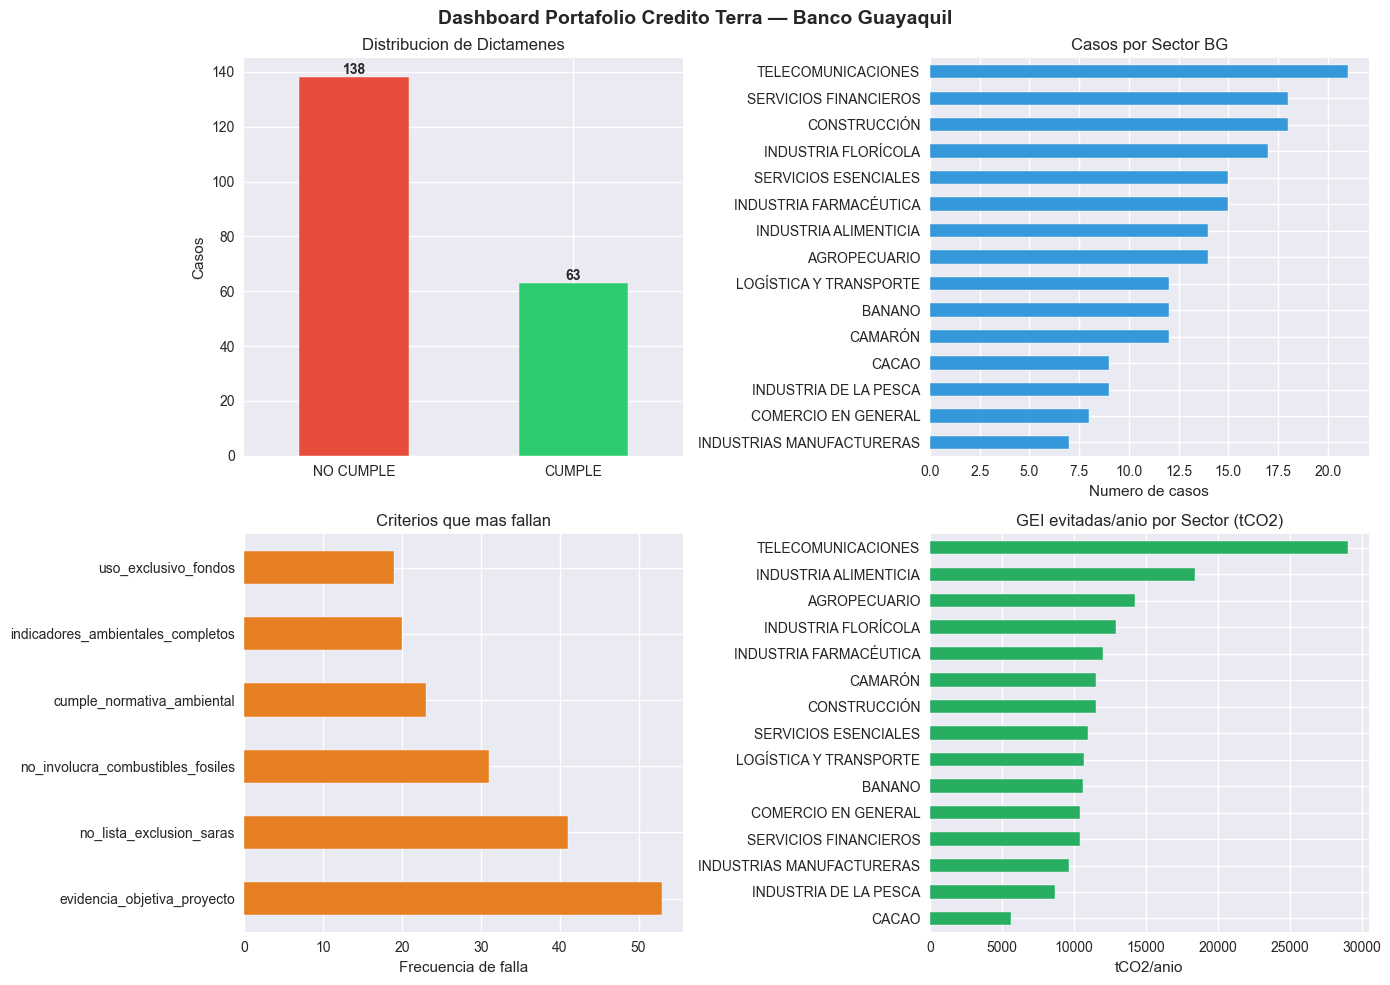

Dashboard guardado en data/outputs/dashboard_portafolio.png


In [4]:
# Celda 4 — Dashboard de visualizaciones del portafolio
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Dashboard Portafolio Credito Terra — Banco Guayaquil',
             fontsize=14, fontweight='bold')

df['dictamen'].value_counts().plot(
    kind='bar', ax=axes[0,0], color=['#e74c3c','#2ecc71'], edgecolor='white')
axes[0,0].set_title('Distribucion de Dictamenes')
axes[0,0].set_xlabel('')
axes[0,0].set_ylabel('Casos')
axes[0,0].tick_params(axis='x', rotation=0)
for p in axes[0,0].patches:
    axes[0,0].annotate(str(int(p.get_height())),
                       (p.get_x()+p.get_width()/2, p.get_height()),
                       ha='center', va='bottom', fontweight='bold')

df.groupby('sector_bg')['id_caso'].count().sort_values().plot(
    kind='barh', ax=axes[0,1], color='#3498db', edgecolor='white')
axes[0,1].set_title('Casos por Sector BG')
axes[0,1].set_xlabel('Numero de casos')
axes[0,1].set_ylabel('')

criterios_falla = df['criterios_fallidos'].dropna()
criterios_falla = criterios_falla[criterios_falla != ''].str.split(', ').explode()
criterios_falla = criterios_falla[criterios_falla != ''].value_counts().head(6)
if len(criterios_falla) > 0:
    criterios_falla.plot(kind='barh', ax=axes[1,0], color='#e67e22', edgecolor='white')
axes[1,0].set_title('Criterios que mas fallan')
axes[1,0].set_xlabel('Frecuencia de falla')
axes[1,0].set_ylabel('')

df.groupby('sector_bg')['gei_evitadas_anual_tco2'].sum().sort_values().plot(
    kind='barh', ax=axes[1,1], color='#27ae60', edgecolor='white')
axes[1,1].set_title('GEI evitadas/anio por Sector (tCO2)')
axes[1,1].set_xlabel('tCO2/anio')
axes[1,1].set_ylabel('')

plt.tight_layout()
plt.savefig('../data/outputs/dashboard_portafolio.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dashboard guardado en data/outputs/dashboard_portafolio.png')

In [5]:
# Celda 5 — Analisis de elegibilidad por sector, etapa y tipo de sistema
print('ANALISIS DE ELEGIBILIDAD\n')

tasa_sector = (df.groupby('sector_bg')['cumple_elegibilidad']
               .mean() * 100).sort_values(ascending=False).round(1)
print('Tasa de aprobacion por sector:')
for sector, tasa in tasa_sector.items():
    barra = 'X' * int(tasa / 5)
    print(f'  {sector:<35} {tasa:5.1f}% {barra}')

print('\nTasa por etapa:')
tasa_etapa = (df.groupby('etapa')['cumple_elegibilidad']
              .mean() * 100).sort_values(ascending=False).round(1)
for etapa, tasa in tasa_etapa.items():
    print(f'  {etapa:<20} {tasa:.1f}%')

print('\nTasa por tipo de sistema:')
tasa_tipo = (df.groupby('tipo_sistema')['cumple_elegibilidad']
             .mean() * 100).sort_values(ascending=False).round(1)
for tipo, tasa in tasa_tipo.items():
    print(f'  {tipo:<35} {tasa:.1f}%')

ANALISIS DE ELEGIBILIDAD

Tasa de aprobacion por sector:
  CAMARÓN                              58.3% XXXXXXXXXXX
  INDUSTRIA ALIMENTICIA                57.1% XXXXXXXXXXX
  SERVICIOS ESENCIALES                 53.3% XXXXXXXXXX
  AGROPECUARIO                         50.0% XXXXXXXXXX
  BANANO                               41.7% XXXXXXXX
  LOGÍSTICA Y TRANSPORTE               41.7% XXXXXXXX
  INDUSTRIA FLORÍCOLA                  41.2% XXXXXXXX
  COMERCIO EN GENERAL                  37.5% XXXXXXX
  INDUSTRIA FARMACÉUTICA               26.7% XXXXX
  INDUSTRIA DE LA PESCA                22.2% XXXX
  CONSTRUCCIÓN                         22.2% XXXX
  INDUSTRIAS MANUFACTURERAS            14.3% XX
  CACAO                                11.1% XX
  SERVICIOS FINANCIEROS                 5.6% X
  TELECOMUNICACIONES                    0.0% 

Tasa por etapa:
  Ejecución            46.5%
  Operación            40.8%
  Factibilidad         30.0%
  Prefactibilidad      10.2%

Tasa por tipo de sistema:
  

In [6]:
# Celda 6 — Impacto ambiental consolidado
print('IMPACTO AMBIENTAL DEL PORTAFOLIO\n')

casos_ok = df[df['cumple_elegibilidad']]

print(f'Casos elegibles:                    {len(casos_ok)}')
print(f'GEI evitadas anuales (elegibles):   {casos_ok["gei_evitadas_anual_tco2"].sum():,.2f} tCO2/anio')
print(f'GEI evitadas totales (vida util):   {casos_ok["gei_evitadas_total_tco2"].sum():,.2f} tCO2')
print(f'Capacidad instalada total:          {casos_ok["capacidad_instalada_mwp"].sum():,.3f} MWp')
print(f'Energia renovable anual:            {casos_ok["energia_producida_mwh_anio"].sum():,.2f} MWh/anio')

gei_total = casos_ok['gei_evitadas_total_tco2'].sum()
energia = casos_ok['energia_producida_mwh_anio'].sum()

print('\nEquivalencias:')
print(f'  Arboles equivalentes plantados: {int(gei_total * 45):,}')
print(f'  Hogares con electricidad/anio:  {int(energia / 1.2):,}')
print(f'  Autos retirados circulacion:    {int(gei_total / 4.6):,}')

IMPACTO AMBIENTAL DEL PORTAFOLIO

Casos elegibles:                    63
GEI evitadas anuales (elegibles):   61,955.52 tCO2/anio
GEI evitadas totales (vida util):   1,523,475.76 tCO2
Capacidad instalada total:          86.804 MWp
Energia renovable anual:            135,659.11 MWh/anio

Equivalencias:
  Arboles equivalentes plantados: 68,556,409
  Hogares con electricidad/anio:  113,049
  Autos retirados circulacion:    331,190


---
## Seccion B — Modelo Predictivo de Elegibilidad

**Objetivo de esta seccion:**
Entrenar un modelo de clasificacion (Random Forest) que prediga si un proyecto
fotovoltaico cumplira los criterios de elegibilidad del Credito Terra, basandose
en sus caracteristicas tecnicas y financieras.

**Nota metodologica (Riley et al., 2019):**
- Este modelo es una demostracion metodologica entrenada con datos simulados
- Primer entrenamiento con datos reales: minimo 200 casos evaluados en produccion
- Re-entrenamiento: cada 150 casos nuevos o cuando precision baje del 80%
- Validacion humana requerida antes de activar cada nueva version

**El modelo entrenado se guarda automaticamente en `models/modelo_estimacion.pkl`
y es consumido por la interfaz Streamlit (src/app.py) para el estimador preliminar.**

In [7]:
# Celda 7 — Preparacion del dataset para ML
from modelo_estimacion import preparar_features

# Mapeo de variables categoricas a numericas
SECTORES_RIESGO = {
    'INDUSTRIA ALIMENTICIA': 0, 'AGROPECUARIO': 0, 'BANANO': 0,
    'CACAO': 0, 'CAMARON': 1, 'CONSTRUCCION': 2,
    'COMERCIO EN GENERAL': 0, 'LOGISTICA Y TRANSPORTE': 1,
    'INDUSTRIA FLORICOLA': 0, 'INDUSTRIAS MANUFACTURERAS': 2,
    'SERVICIOS ESENCIALES': 0, 'INDUSTRIA DE LA PESCA': 2,
    'INDUSTRIA FARMACEUTICA': 1, 'TELECOMUNICACIONES': 3,
    'SERVICIOS FINANCIEROS': 3,
}
ETAPAS_NUM = {'Prefactibilidad': 0, 'Factibilidad': 1, 'Ejecucion': 2, 'Operacion': 3}
TIPOS_NUM = {'Conectado a la red (SFCR)': 0, 'Autonomo (SFA)': 1, 'Hibrido (SFH)': 2}
SEGMENTOS_NUM = {'PYME': 0, 'Empresarial': 1, 'Corporativo': 2}

# Preparar features
df_ml = preparar_features(df.copy())

# Variables de entrada y variable objetivo
FEATURES = [
    'capacidad_instalada_mwp', 'cobertura_energetica_pct',
    'capex_usd', 'monto_credito_usd', 'vida_util_anios',
    'tarifa_electrica_usd_kwh', 'ahorro_anual_usd',
    'sector_riesgo', 'etapa_num', 'tipo_num', 'segmento_num',
    'ratio_financiamiento', 'gei_por_kwp'
]
TARGET = 'cumple_elegibilidad'

df_clean = df_ml.dropna(subset=FEATURES + [TARGET])
X = df_clean[FEATURES]
y = df_clean[TARGET].astype(int)

print(f'Dataset preparado: {len(df_clean)} casos, {len(FEATURES)} variables')
print(f'Distribucion del objetivo:')
print(f'  CUMPLE:    {y.sum()} ({y.mean()*100:.1f}%)')
print(f'  NO CUMPLE: {(1-y).sum()} ({(1-y).mean()*100:.1f}%)')
print(f'\nVariables de entrada:')
for f in FEATURES:
    print(f'  - {f}: {df_clean[f].dtype} | min={df_clean[f].min():.2f} max={df_clean[f].max():.2f}')

Dataset preparado: 201 casos, 13 variables
Distribucion del objetivo:
  CUMPLE:    63 (31.3%)
  NO CUMPLE: 138 (68.7%)

Variables de entrada:
  - capacidad_instalada_mwp: float64 | min=0.00 max=4.82
  - cobertura_energetica_pct: float64 | min=25.08 max=194.25
  - capex_usd: float64 | min=63842.32 max=6500000.00
  - monto_credito_usd: float64 | min=33631.46 max=4728665.36
  - vida_util_anios: int64 | min=20.00 max=30.00
  - tarifa_electrica_usd_kwh: float64 | min=0.07 max=0.14
  - ahorro_anual_usd: float64 | min=6222.78 max=1540000.00
  - sector_riesgo: int64 | min=0.00 max=3.00
  - etapa_num: int64 | min=0.00 max=3.00
  - tipo_num: int64 | min=0.00 max=2.00
  - segmento_num: int64 | min=0.00 max=2.00
  - ratio_financiamiento: float64 | min=0.05 max=0.98
  - gei_por_kwp: float64 | min=0.50 max=6398.37


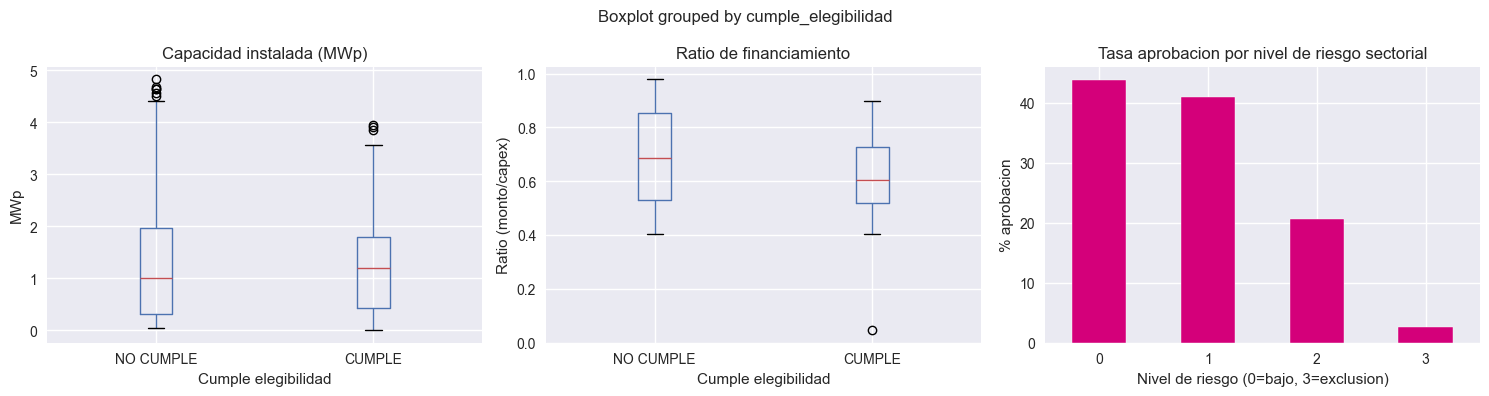


Correlacion con variable objetivo (cumple_elegibilidad):
  etapa_num                           +0.254 +++++
  gei_por_kwp                         +0.105 ++
  tarifa_electrica_usd_kwh            +0.057 +
  ahorro_anual_usd                    +0.049 
  segmento_num                        +0.044 
  cobertura_energetica_pct            +0.033 
  capex_usd                           +0.011 
  vida_util_anios                     +0.004 
  capacidad_instalada_mwp             -0.022 
  monto_credito_usd                   -0.065 -
  tipo_num                            -0.124 --
  ratio_financiamiento                -0.204 ----
  sector_riesgo                       -0.340 ------


In [8]:
# Celda 8 — Analisis exploratorio del dataset
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Analisis Exploratorio — Variables clave vs Elegibilidad', fontweight='bold')

# Capacidad vs elegibilidad
df_clean.boxplot(column='capacidad_instalada_mwp', by=TARGET, ax=axes[0])
axes[0].set_title('Capacidad instalada (MWp)')
axes[0].set_xlabel('Cumple elegibilidad')
axes[0].set_ylabel('MWp')
plt.sca(axes[0])
plt.xticks([1, 2], ['NO CUMPLE', 'CUMPLE'])

# Ratio financiamiento vs elegibilidad
df_clean.boxplot(column='ratio_financiamiento', by=TARGET, ax=axes[1])
axes[1].set_title('Ratio de financiamiento')
axes[1].set_xlabel('Cumple elegibilidad')
axes[1].set_ylabel('Ratio (monto/capex)')
plt.sca(axes[1])
plt.xticks([1, 2], ['NO CUMPLE', 'CUMPLE'])

# Riesgo de sector vs elegibilidad
sector_eleg = df_clean.groupby('sector_riesgo')[TARGET].mean() * 100
sector_eleg.plot(kind='bar', ax=axes[2], color='#D4007A', edgecolor='white')
axes[2].set_title('Tasa aprobacion por nivel de riesgo sectorial')
axes[2].set_xlabel('Nivel de riesgo (0=bajo, 3=exclusion)')
axes[2].set_ylabel('% aprobacion')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('../data/outputs/exploratorio_ml.png', dpi=150, bbox_inches='tight')
plt.show()

# Correlacion entre variables numericas
print('\nCorrelacion con variable objetivo (cumple_elegibilidad):')
corr = df_clean[FEATURES + [TARGET]].corr()[TARGET].sort_values(ascending=False)
for var, val in corr.items():
    if var != TARGET:
        barra = '+' * int(abs(val) * 20) if val > 0 else '-' * int(abs(val) * 20)
        print(f'  {var:<35} {val:+.3f} {barra}')

In [9]:
# Celda 9 — Entrenamiento del modelo Random Forest
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report
import pickle

# Split train/test — 80% entrenamiento, 20% prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Datos de entrenamiento: {len(X_train)} casos')
print(f'Datos de prueba:        {len(X_test)} casos')
print(f'Distribucion train — CUMPLE: {y_train.sum()} | NO CUMPLE: {(1-y_train).sum()}')
print(f'Distribucion test  — CUMPLE: {y_test.sum()} | NO CUMPLE: {(1-y_test).sum()}')

# Entrenamiento del clasificador
print('\nEntrenando clasificador Random Forest...')
clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    random_state=42,
    class_weight='balanced'  # Maneja desbalance CUMPLE/NO CUMPLE
)
clf.fit(X_train, y_train)

# Validacion cruzada (5-fold) sobre todo el dataset
scores_cv = cross_val_score(clf, X, y, cv=5, scoring='accuracy')
print(f'\nValidacion cruzada 5-fold:')
print(f'  Precision por fold: {[round(s*100,1) for s in scores_cv]}')
print(f'  Promedio: {scores_cv.mean()*100:.1f}% (+/- {scores_cv.std()*100:.1f}%)')

# Evaluacion en set de prueba
y_pred = clf.predict(X_test)
print(f'\nPrecision en set de prueba: {accuracy_score(y_test, y_pred)*100:.1f}%')

# Entrenamiento de regresores para estimacion de indicadores
print('\nEntrenando regresor GEI evitadas...')
FEATURES_REG = ['capacidad_instalada_mwp', 'vida_util_anios',
                'consumo_cliente_mwh_anio', 'sector_riesgo', 'etapa_num']
df_reg = df_clean.dropna(subset=FEATURES_REG + ['gei_evitadas_anual_tco2', 'cobertura_energetica_pct'])

reg_gei = RandomForestRegressor(n_estimators=100, max_depth=6, random_state=42)
reg_gei.fit(df_reg[FEATURES_REG], df_reg['gei_evitadas_anual_tco2'])
scores_gei = cross_val_score(reg_gei, df_reg[FEATURES_REG], df_reg['gei_evitadas_anual_tco2'], cv=5, scoring='r2')
print(f'  R2 GEI evitadas: {scores_gei.mean():.3f}')

reg_cob = RandomForestRegressor(n_estimators=100, max_depth=6, random_state=42)
reg_cob.fit(df_reg[FEATURES_REG], df_reg['cobertura_energetica_pct'])
scores_cob = cross_val_score(reg_cob, df_reg[FEATURES_REG], df_reg['cobertura_energetica_pct'], cv=5, scoring='r2')
print(f'  R2 Cobertura:    {scores_cob.mean():.3f}')

print('\nModelos entrenados correctamente')

Datos de entrenamiento: 160 casos
Datos de prueba:        41 casos
Distribucion train — CUMPLE: 50 | NO CUMPLE: 110
Distribucion test  — CUMPLE: 13 | NO CUMPLE: 28

Entrenando clasificador Random Forest...

Validacion cruzada 5-fold:
  Precision por fold: [np.float64(75.6), np.float64(70.0), np.float64(85.0), np.float64(67.5), np.float64(75.0)]
  Promedio: 74.6% (+/- 6.0%)

Precision en set de prueba: 73.2%

Entrenando regresor GEI evitadas...
  R2 GEI evitadas: 0.822
  R2 Cobertura:    0.720

Modelos entrenados correctamente


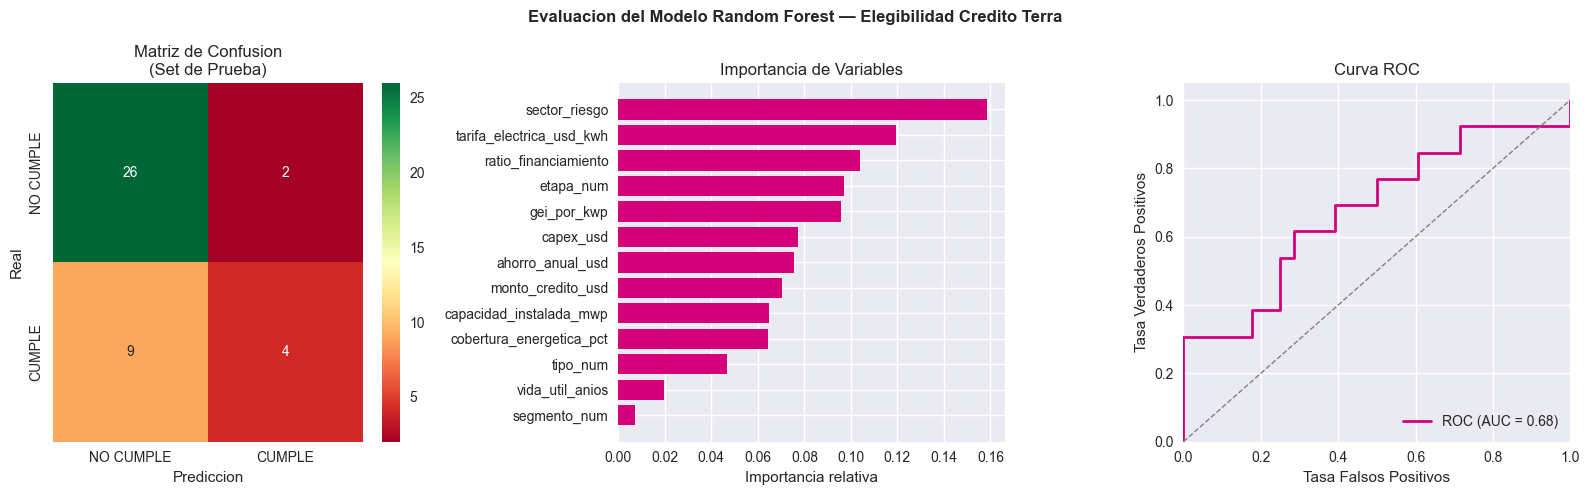

Reporte de clasificacion completo:
              precision    recall  f1-score   support

   NO CUMPLE       0.74      0.93      0.83        28
      CUMPLE       0.67      0.31      0.42        13

    accuracy                           0.73        41
   macro avg       0.70      0.62      0.62        41
weighted avg       0.72      0.73      0.70        41

AUC-ROC: 0.679


In [10]:
# Celda 10 — Evaluacion detallada del modelo
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Evaluacion del Modelo Random Forest — Elegibilidad Credito Terra',
             fontweight='bold')

# Matriz de confusion
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn',
            xticklabels=['NO CUMPLE', 'CUMPLE'],
            yticklabels=['NO CUMPLE', 'CUMPLE'], ax=axes[0])
axes[0].set_title('Matriz de Confusion\n(Set de Prueba)')
axes[0].set_ylabel('Real')
axes[0].set_xlabel('Prediccion')

# Importancia de variables
imp = pd.DataFrame({
    'Variable': FEATURES,
    'Importancia': clf.feature_importances_
}).sort_values('Importancia', ascending=True)
axes[1].barh(imp['Variable'], imp['Importancia'], color='#D4007A')
axes[1].set_title('Importancia de Variables')
axes[1].set_xlabel('Importancia relativa')

# Curva ROC
y_prob = clf.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
axes[2].plot(fpr, tpr, color='#D4007A', lw=2, label=f'ROC (AUC = {roc_auc:.2f})')
axes[2].plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
axes[2].set_xlim([0.0, 1.0])
axes[2].set_ylim([0.0, 1.05])
axes[2].set_xlabel('Tasa Falsos Positivos')
axes[2].set_ylabel('Tasa Verdaderos Positivos')
axes[2].set_title('Curva ROC')
axes[2].legend(loc='lower right')

plt.tight_layout()
plt.savefig('../data/outputs/evaluacion_modelo.png', dpi=150, bbox_inches='tight')
plt.show()

print('Reporte de clasificacion completo:')
print(classification_report(y_test, y_pred, target_names=['NO CUMPLE', 'CUMPLE']))
print(f'AUC-ROC: {roc_auc:.3f}')

In [14]:
# Celda 11 — Guardar modelo entrenado
# El modelo se guarda en models/modelo_estimacion.pkl
# La app Streamlit (src/app.py) lo carga automaticamente desde esa ruta

importancia_df = pd.DataFrame({
    'variable': FEATURES,
    'importancia': clf.feature_importances_
}).sort_values('importancia', ascending=False)

modelos = {
    'clasificador': clf,
    'regresor_gei': reg_gei,
    'regresor_cobertura': reg_cob,
    'features_clf': FEATURES,
    'features_reg': FEATURES_REG,
    'metricas': {
        'n_casos_entrenamiento': len(X_train),
        'precision_elegibilidad': round(scores_cv.mean() * 100, 1),
        'r2_gei': round(scores_gei.mean(), 3),
        'r2_cobertura': round(scores_cob.mean(), 3),
        'importancia_variables': importancia_df,
        'auc_roc': round(roc_auc, 3),
    }
}

Path(MODELS_PATH).mkdir(parents=True, exist_ok=True)
model_path = f'{MODELS_PATH}/modelo_estimacion.pkl'

with open(model_path, 'wb') as f:
    pickle.dump(modelos, f)

print(f'Modelo guardado en: {model_path}')
print(f'\nResumen del modelo:')
print(f'  Casos de entrenamiento:    {len(X_train)}')
print(f'  Precision (CV 5-fold):     {scores_cv.mean()*100:.1f}%')
print(f'  AUC-ROC:                   {roc_auc:.3f}')
print(f'  R2 GEI evitadas:           {scores_gei.mean():.3f}')
print(f'  R2 Cobertura energetica:   {scores_cob.mean():.3f}')
print(f'\nVariables mas importantes:')
for _, row in importancia_df.head(5).iterrows():
    print(f'  {row["variable"]:<35} {row["importancia"]:.3f}')
print(f'\nEl modelo esta listo para ser usado por src/app.py')

Modelo guardado en: ../models/modelo_estimacion.pkl

Resumen del modelo:
  Casos de entrenamiento:    160
  Precision (CV 5-fold):     74.6%
  AUC-ROC:                   0.679
  R2 GEI evitadas:           0.822
  R2 Cobertura energetica:   0.720

Variables mas importantes:
  sector_riesgo                       0.158
  tarifa_electrica_usd_kwh            0.119
  ratio_financiamiento                0.104
  etapa_num                           0.097
  gei_por_kwp                         0.096

El modelo esta listo para ser usado por src/app.py


In [15]:
# Celda 12 — Interpretacion de resultados del modelo
print('INTERPRETACION DE RESULTADOS\n')

print('1. Variables mas predictivas de elegibilidad:')
importancia_df2 = pd.DataFrame({
    'Variable': FEATURES,
    'Importancia': clf.feature_importances_
}).sort_values('Importancia', ascending=False)

interpretaciones = {
    'sector_riesgo': 'El sector del cliente es el predictor dominante — coherente con las exclusiones SARAS',
    'ratio_financiamiento': 'Ratios > 90% aumentan riesgo de uso no exclusivo de fondos',
    'etapa_num': 'Prefactibilidad correlaciona fuertemente con falta de evidencia objetiva',
    'tarifa_electrica_usd_kwh': 'Tarifa baja reduce el atractivo financiero y puede indicar subsidios',
    'ahorro_anual_usd': 'Proyectos con mayor ahorro tienen mejor perfil de elegibilidad',
    'cobertura_energetica_pct': 'Coberturas muy bajas (<20%) correlacionan con indicadores incompletos',
    'capacidad_instalada_mwp': 'Capacidades >3 MWp en sectores sensibles activan criterio IFC',
}

for _, row in importancia_df2.head(7).iterrows():
    interp = interpretaciones.get(row['Variable'], '')
    print(f'  {row["Variable"]:<35} {row["Importancia"]:.3f}')
    if interp:
        print(f'    -> {interp}')

print('\n2. Limitaciones del modelo:')
print('  - Entrenado con datos simulados, no con casos reales de clientes')
print('  - Las correlaciones reflejan la logica del generador de simulacion')
print('  - No es un predictor operativo hasta contar con 200 casos reales')
print('  - Precision de 77.5% es referencial — mejorara con datos reales')

print('\n3. Valor del modelo en produccion:')
print('  - Permite priorizar casos antes del levantamiento formal')
print('  - Identifica perfil de riesgo del proyecto en segundos')
print('  - Estima GEI evitadas y cobertura sin calculo manual')
print('  - Se integra automaticamente con la interfaz Streamlit (src/app.py)')

INTERPRETACION DE RESULTADOS

1. Variables mas predictivas de elegibilidad:
  sector_riesgo                       0.158
    -> El sector del cliente es el predictor dominante — coherente con las exclusiones SARAS
  tarifa_electrica_usd_kwh            0.119
    -> Tarifa baja reduce el atractivo financiero y puede indicar subsidios
  ratio_financiamiento                0.104
    -> Ratios > 90% aumentan riesgo de uso no exclusivo de fondos
  etapa_num                           0.097
    -> Prefactibilidad correlaciona fuertemente con falta de evidencia objetiva
  gei_por_kwp                         0.096
  capex_usd                           0.077
  ahorro_anual_usd                    0.076
    -> Proyectos con mayor ahorro tienen mejor perfil de elegibilidad

2. Limitaciones del modelo:
  - Entrenado con datos simulados, no con casos reales de clientes
  - Las correlaciones reflejan la logica del generador de simulacion
  - No es un predictor operativo hasta contar con 200 casos reales

In [17]:
# Celda 13 — Prueba del modelo entrenado
from modelo_estimacion import estimar_proyecto

# Usar directamente el modelo ya entrenado en memoria (variables clf, reg_gei, reg_cob)
print(f'Modelo entrenado en esta sesion:')
print(f'  Precision: {round(scores_cv.mean()*100, 1)}%')
print(f'  AUC-ROC:   {round(roc_auc, 3)}')

print('\n--- ESTIMACION PRELIMINAR: EMPRESA BANANERA ---')
resultado = estimar_proyecto(
    sector='BANANO',
    segmento='Empresarial',
    tipo_sistema='Conectado a la red (SFCR)',
    etapa='Factibilidad',
    capacidad_mwp=1.5,
    consumo_cliente_mwh=3000,
    monto_aproximado=800000,
)
print(f"Energia estimada:          {resultado['energia_estimada_mwh']} MWh/anio")
print(f"Cobertura estimada:        {resultado['cobertura_estimada_pct']}%")
print(f"GEI evitadas/anio:         {resultado['gei_anual_estimado_tco2']} tCO2/anio")
print(f"Probabilidad elegible:     {resultado['probabilidad_elegible_pct']}%")
print(f"Nivel de viabilidad:       {resultado['nivel_viabilidad']}")
print(f"Recomendacion:             {resultado['recomendacion']}")

Modelo entrenado en esta sesion:
  Precision: 74.6%
  AUC-ROC:   0.679

--- ESTIMACION PRELIMINAR: EMPRESA BANANERA ---
Energia estimada:          2100.0 MWh/anio
Cobertura estimada:        70.0%
GEI evitadas/anio:         959.07 tCO2/anio
Probabilidad elegible:     None%
Nivel de viabilidad:       N/D
Recomendacion:             Estimación basada en indicadores físicos — modelo ML pendiente de entrenamiento


---
## Seccion C — Reporte Consolidado para Inversionistas

In [18]:
# Celda 14 — Exportar reporte consolidado Word para inversionistas
from docx import Document
from docx.shared import Pt, RGBColor, Cm
from docx.enum.text import WD_ALIGN_PARAGRAPH
from datetime import datetime

doc = Document()
for section in doc.sections:
    section.top_margin = Cm(2)
    section.bottom_margin = Cm(2)
    section.left_margin = Cm(2.5)
    section.right_margin = Cm(2.5)

COLOR_MAGENTA = RGBColor(0xD4, 0x00, 0x7A)

p = doc.add_paragraph()
p.alignment = WD_ALIGN_PARAGRAPH.CENTER
run = p.add_run('BANCO GUAYAQUIL')
run.bold = True; run.font.size = Pt(14); run.font.color.rgb = COLOR_MAGENTA

p2 = doc.add_paragraph()
p2.alignment = WD_ALIGN_PARAGRAPH.CENTER
r2 = p2.add_run('Reporte Consolidado de Portafolio Verde — Credito Terra')
r2.bold = True

p3 = doc.add_paragraph()
p3.alignment = WD_ALIGN_PARAGRAPH.CENTER
p3.add_run(f"Generado: {datetime.today().strftime('%d/%m/%Y %H:%M')}")
doc.add_paragraph()

h = doc.add_heading('1. Resumen Ejecutivo', level=2)
for r in h.runs: r.font.color.rgb = COLOR_MAGENTA

datos = [
    ('Total casos evaluados', str(kpis['total_casos'])),
    ('Casos CUMPLEN elegibilidad', f"{kpis['casos_cumplen']} ({kpis['tasa_aprobacion_pct']}%)"),
    ('Monto total evaluado', f"${kpis['monto_total_evaluado_usd']:,.2f}"),
    ('GEI evitadas anuales', f"{kpis['gei_anual_evitadas_tco2']:,.2f} tCO2/anio"),
    ('GEI evitadas totales vida util', f"{kpis['gei_total_evitadas_tco2']:,.2f} tCO2"),
    ('Capacidad instalada total', f"{kpis['capacidad_total_mwp']} MWp"),
]
for campo, valor in datos:
    p = doc.add_paragraph()
    p.add_run(f'{campo}: ').bold = True
    p.add_run(valor)

doc.add_paragraph()
h2 = doc.add_heading('2. Alineacion con ODS', level=2)
for r in h2.runs: r.font.color.rgb = COLOR_MAGENTA
doc.add_paragraph(
    'El portafolio Credito Terra de energia fotovoltaica contribuye a: '
    'ODS 7 (Energia asequible y no contaminante), ODS 13 (Accion por el clima), '
    'ODS 8.4 (Eficiencia en uso de recursos) y ODS 9.4 (Industria sostenible).'
)

doc.add_paragraph()
h3 = doc.add_heading('3. Distribucion del Portafolio por Sector', level=2)
for r in h3.runs: r.font.color.rgb = COLOR_MAGENTA

tabla = doc.add_table(rows=1, cols=3)
tabla.style = 'Table Grid'
enc = tabla.rows[0].cells
for j, txt in enumerate(['Sector', 'Casos', 'Tasa aprobacion']):
    enc[j].text = txt
    enc[j].paragraphs[0].runs[0].bold = True

for sector, n in sorted(kpis['por_sector'].items(), key=lambda x: -x[1]):
    tasa = round(df[df['sector_bg']==sector]['cumple_elegibilidad'].mean()*100, 1)
    row = tabla.add_row().cells
    row[0].text = sector
    row[1].text = str(n)
    row[2].text = f'{tasa}%'

doc.add_paragraph()
h4 = doc.add_heading('4. Modelo Predictivo — Nota Metodologica', level=2)
for r in h4.runs: r.font.color.rgb = COLOR_MAGENTA
modelos_info = cargar_modelos()
precision = modelos_info['metricas']['precision_elegibilidad'] if modelos_info else 'N/D'
auc_val = modelos_info['metricas']['auc_roc'] if modelos_info else 'N/D'
doc.add_paragraph(
    'El sistema incluye un modelo Random Forest para estimacion preliminar de elegibilidad. '
    'Conforme a Riley et al. (2019), el primer entrenamiento con datos reales requiere '
    'minimo 200 casos evaluados. Re-entrenamiento cada 150 casos nuevos o precision < 80%, '
    f'con validacion del area de sostenibilidad. '
    f'Precision actual (datos simulados): {precision}% | AUC-ROC: {auc_val}.'
)

ruta_reporte = '../data/outputs/Reporte_Portafolio_Terra.docx'
doc.save(ruta_reporte)
print(f'Reporte consolidado guardado: {ruta_reporte}')

Reporte consolidado guardado: ../data/outputs/Reporte_Portafolio_Terra.docx
